# Linear Regression - Calc of Resistance
language: Julia

In [1]:
using StatsPlots, Plots, DelimitedFiles, Statistics

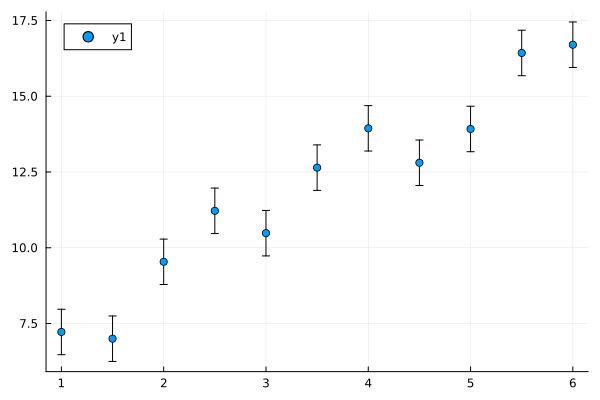

In [2]:
data= readdlm("mcmc.dat")
x = data[1, :]
y = data[2, :]
sigma=0.75

scatter(x, y; yerror=sigma)
# uuuuuuh stylish

5.314365333636355 a_ml
1.9073159072727293 b_ml


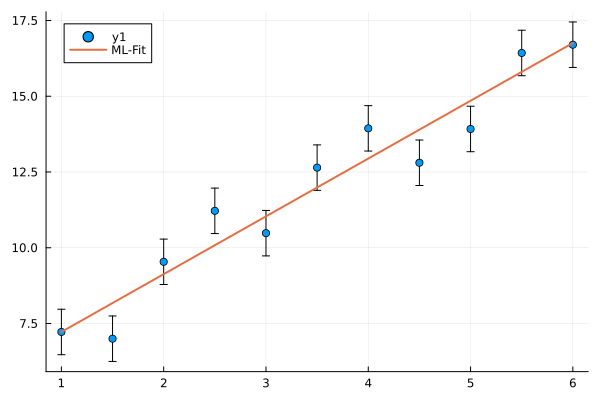

In [3]:
xy_m= mean(x.*y)
x2_m= mean(x.^2)
x_m= mean(x)
y_m= mean(y)
b_ml = (xy_m - x_m * y_m) / (x2_m - x_m^2)    #geliefert durch maximieren der log Likelihoof
a_ml = y_m - b_ml * x_m

println(a_ml, " a_ml")
println(b_ml, " b_ml")

scatter(x, y; yerror=sigma)
plot!(x -> a_ml + b_ml * x,
         extrema(x)...; 
         label="ML-Fit", 
         lw=2)



MCMC-Mittelwerte: ⟨a⟩ = 5.3378, ⟨b⟩ = 1.9021


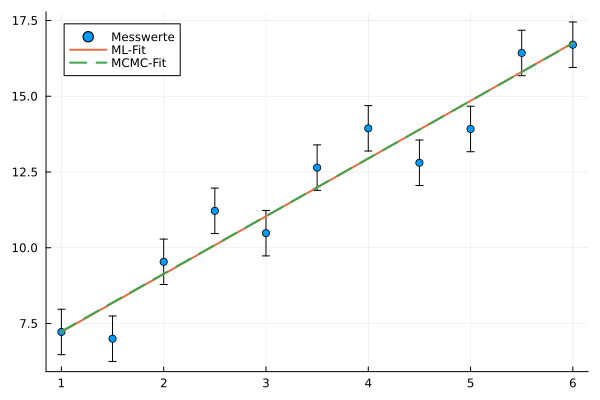

In [4]:
# Log-Likelihood-Funktion
function log_likelihood(a, b, x, y, sigma)
    model = a .+ b .* x
    return -sum((y .- model).^2) / (2 * sigma^2)
end

# MCMC Parameter 
a0, b0 = a_ml, b_ml         # Startwerte aus ML-Schätzung
da, db = 0.5, 0.5           # Schrittweiten
N_mess = 10_000
N_skip = 20
N_loop = N_mess * N_skip

#MCMC Initialisierung
a, b = a0, b0
p0 = log_likelihood(a, b, x, y, sigma)
chain = zeros(N_loop, 2)

# Metropolis-Hastings Loop
for i in 1:N_loop
    a_t = a + (rand() - 0.5) * da
    b_t = b + (rand() - 0.5) * db
    p_t = log_likelihood(a_t, b_t, x, y, sigma)

    if rand() < min(1, exp(p_t - p0))
        a, b = a_t, b_t
        p0 = p_t
    end

    chain[i, :] = [a, b]
end

# Dekorrelation
samples = chain[1:N_skip:end, :]
a_mcmc_mean = mean(samples[:, 1])
b_mcmc_mean = mean(samples[:, 2])

println("MCMC-Mittelwerte: ⟨a⟩ = $(round(a_mcmc_mean, digits=4)), ⟨b⟩ = $(round(b_mcmc_mean, digits=4))")
#note that i do not have anexact idea how this works xDDDDD

scatter(x, y; yerror=sigma, label="Messwerte")
plot!(x -> a_ml + b_ml * x, extrema(x)...; label="ML-Fit", lw=2)
plot!(x -> a_mcmc_mean + b_mcmc_mean * x, extrema(x)...; label="MCMC-Fit", lw=2, ls=:dash)